In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
mlg_ulb_creditcardfraud_path = kagglehub.dataset_download('mlg-ulb/creditcardfraud')

print('Data source import complete.')


Using Colab cache for faster access to the 'creditcardfraud' dataset.
Data source import complete.


In [ ]:
import pandas as pd
import numpy as np
from pandas import DataFrame
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn import preprocessing
import imblearn
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import auc
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load the dataset
dataset = '/kaggle/input/creditcardfraud/creditcard.csv'
df = pd.read_csv(dataset)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# checking the number of missing values in each column
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


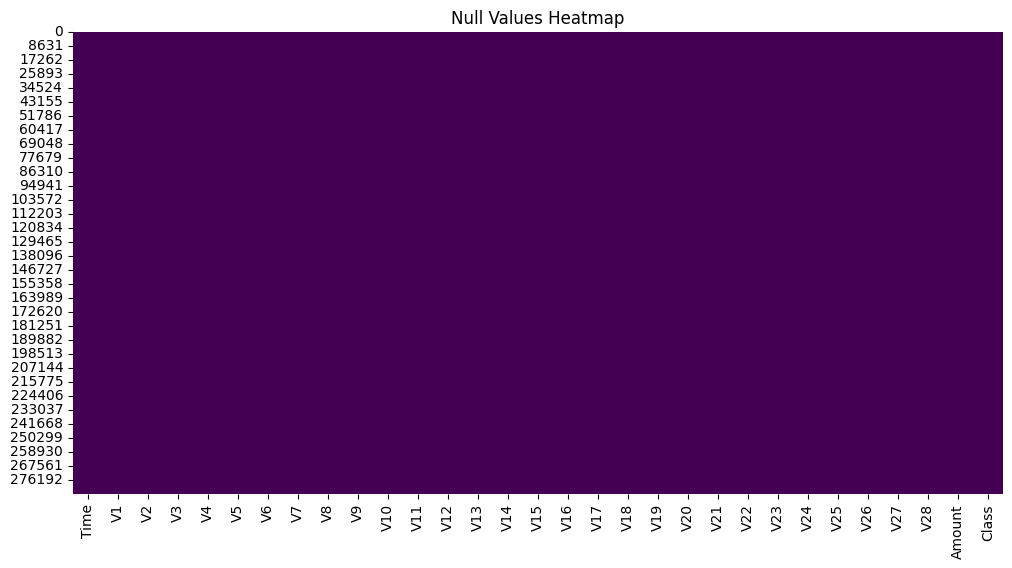

In [ ]:
# Set figure size
plt.figure(figsize=(12, 6))

# Plot null heatmap
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Null Values Heatmap")
plt.show()


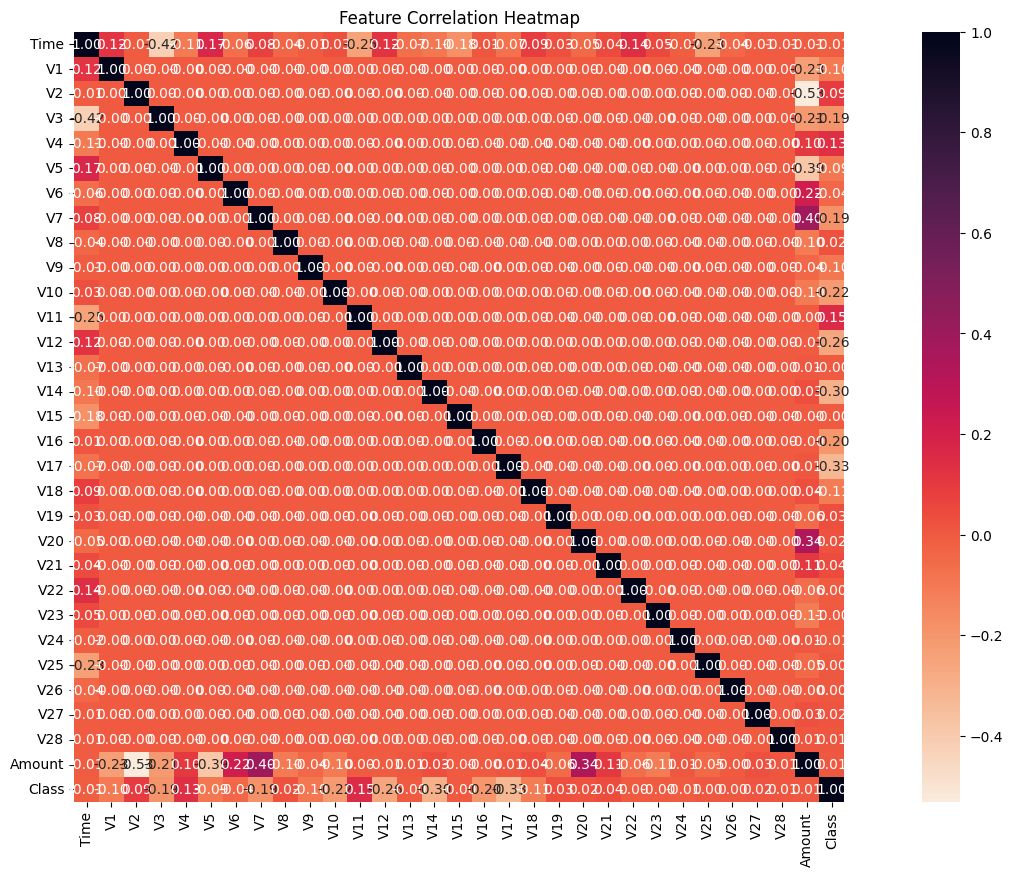

In [ ]:
# Compute correlation matrix
corr_matrix = df.corr()

# Set figure size
plt.figure(figsize=(20, 10))

# Plot the heatmap with values
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='rocket_r', square=True)
plt.title("Feature Correlation Heatmap")
plt.show()

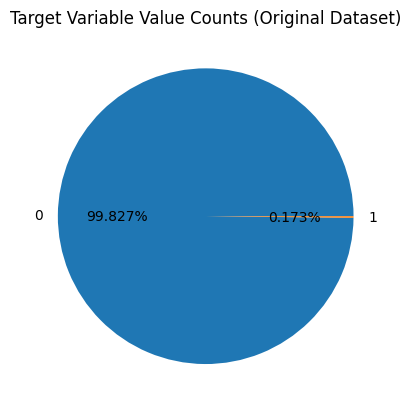

Original Dataset Statistics:
Total samples: 284807
Fraud cases: 492
Non-fraud cases: 284315
Fraud percentage: 0.173%


In [ ]:
# Get the set of distinct classes
labels = df.Class.unique()
sizes = df.Class.value_counts().values

# Plot the class value counts
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.3f%%')
ax.set_title('Target Variable Value Counts (Original Dataset)')
plt.show()

print(f"Original Dataset Statistics:")
print(f"Total samples: {len(df)}")
print(f"Fraud cases: {len(df[df.Class == 1])}")
print(f"Non-fraud cases: {len(df[df.Class == 0])}")
print(f"Fraud percentage: {len(df[df.Class == 1])/len(df)*100:.3f}%")

In [ ]:
# distribution of legit transactions & fraudulent transactions
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [ ]:
credit_card_data = df.drop("Time", axis=1)

In [ ]:
scaler = preprocessing.StandardScaler()

In [ ]:
#standard scaling
credit_card_data['std_Amount'] = scaler.fit_transform(credit_card_data['Amount'].values.reshape (-1,1))

#removing Amount
credit_card_data = credit_card_data.drop("Amount", axis=1)

<Axes: xlabel='Class', ylabel='count'>

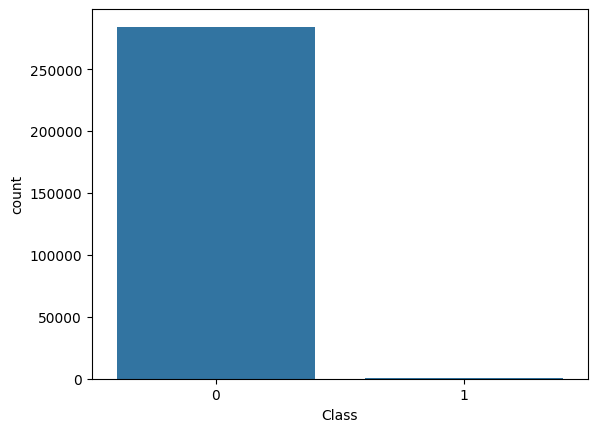

In [ ]:
sns.countplot(x="Class", data=credit_card_data)

In [ ]:
 undersample = RandomUnderSampler(sampling_strategy=0.5)

In [ ]:
cols = credit_card_data.columns.tolist()
cols = [c for c in cols if c not in ["Class"]]
target = "Class"

In [ ]:
#define X and Y
X = credit_card_data[cols]
Y = credit_card_data[target]

#undersample
X_under, Y_under = undersample.fit_resample(X, Y)

In [ ]:
test = pd.DataFrame(Y_under, columns = ['Class'])

Text(0.5, 1.0, 'After')

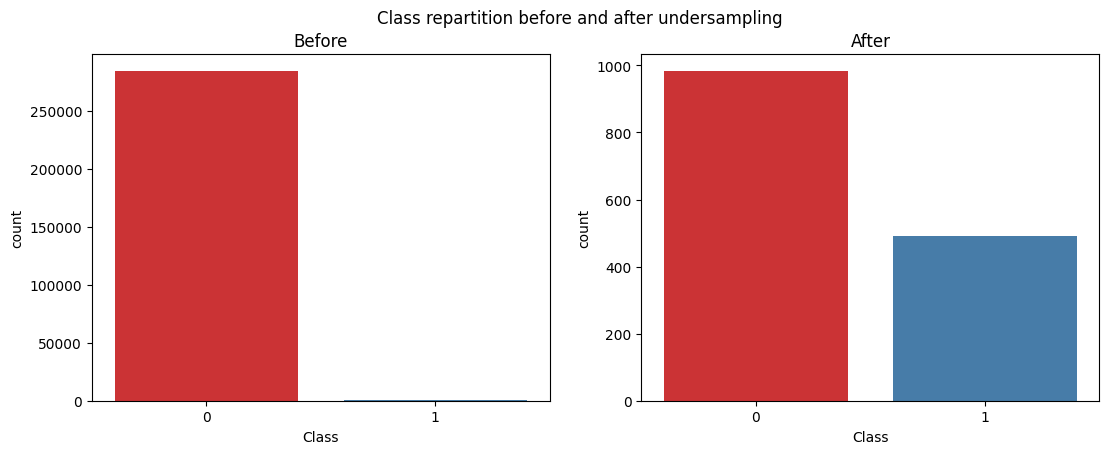

In [ ]:
#visualizing undersampling results
fig, axs = plt.subplots(ncols=2, figsize=(13,4.5))
sns.countplot(x="Class", data=credit_card_data, ax=axs[0], palette="Set1")
sns.countplot(x="Class", data=test, ax=axs[1], palette="Set1")

fig.suptitle("Class repartition before and after undersampling")
a1=fig.axes[0]
a1.set_title("Before")
a2=fig.axes[1]
a2.set_title("After")

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_under, Y_under, test_size=0.2, random_state=1)

In [ ]:
#train the model
#SVM
model1 = SVC(probability=True, random_state=2)
svm = model1.fit(X_train, y_train)

#Logistic Regression
model2 = LogisticRegression()
LR = model2.fit(X_train, y_train)

#Knn
model3 = KNeighborsClassifier(n_neighbors=3)
knn = model3.fit(X_train, y_train)

In [ ]:
#predictions
y_pred_svm = model1.predict(X_test)
y_pred_LR = model2.predict(X_test)
y_pred_knn = model3.predict(X_test)

In [ ]:
#scores
print("Accuracy SVM:",metrics.accuracy_score(y_test, y_pred_svm))
print("Precision SVM:",metrics.precision_score(y_test, y_pred_svm))
print("Recall SVM:",metrics.recall_score(y_test, y_pred_svm))
print("F1 Score SVM:",metrics.f1_score(y_test, y_pred_svm))

print("Accuracy Logistic Regression:",metrics.accuracy_score(y_test, y_pred_LR))
print("Precision Logistic Regression:",metrics.precision_score(y_test, y_pred_LR))
print("Recall Logistic Regression:",metrics.recall_score(y_test, y_pred_LR))
print("F1 Score Logistic Regression:",metrics.f1_score(y_test, y_pred_LR))

print("Accuracy KNN:",metrics.accuracy_score(y_test, y_pred_knn))
print("Precision KNN:",metrics.precision_score(y_test, y_pred_knn))
print("Recall KNN:",metrics.recall_score(y_test, y_pred_knn))
print("F1 Score KNN:",metrics.f1_score(y_test, y_pred_knn))

Accuracy SVM: 0.9493243243243243
Precision SVM: 1.0
Recall SVM: 0.8611111111111112
F1 Score SVM: 0.9253731343283582
Accuracy Logistic Regression: 0.9594594594594594
Precision Logistic Regression: 0.9897959183673469
Recall Logistic Regression: 0.8981481481481481
F1 Score Logistic Regression: 0.941747572815534
Accuracy KNN: 0.956081081081081
Precision KNN: 0.9896907216494846
Recall KNN: 0.8888888888888888
F1 Score KNN: 0.9365853658536586


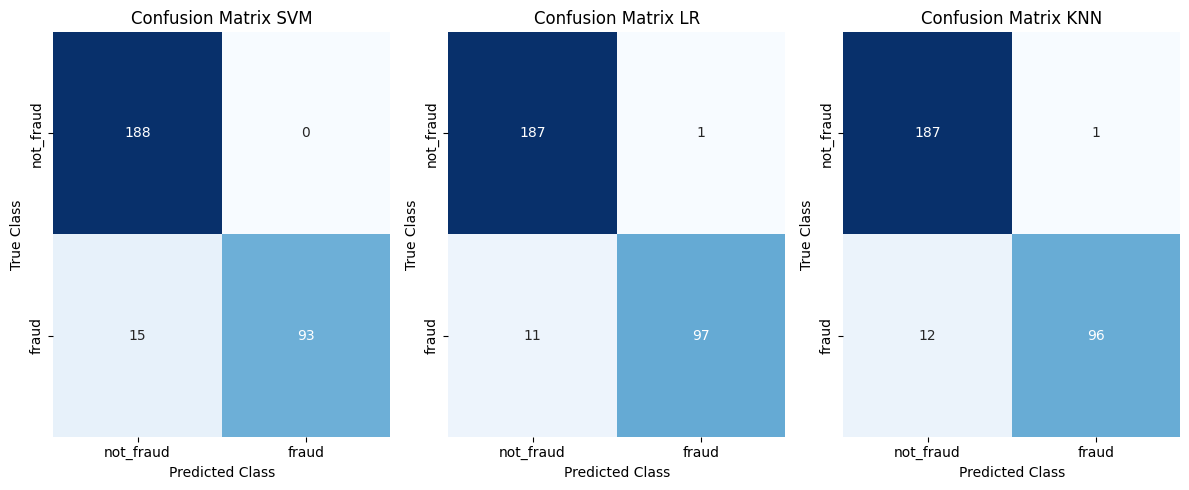

In [ ]:
#CM matrix
matrix_svm = confusion_matrix(y_test, y_pred_svm)
cm_svm = pd.DataFrame(matrix_svm, index=['not_fraud', 'fraud'], columns=['not_fraud', 'fraud'])

matrix_LR = confusion_matrix(y_test, y_pred_LR)
cm_LR = pd.DataFrame(matrix_LR, index=['not_fraud', 'fraud'], columns=['not_fraud', 'fraud'])

matrix_knn = confusion_matrix(y_test, y_pred_knn)
cm_knn = pd.DataFrame(matrix_knn, index=['not_fraud', 'fraud'], columns=['not_fraud', 'fraud'])

# Plot confusion matrices side-by-side
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

sns.heatmap(cm_svm, annot=True, cbar=None, cmap="Blues", fmt='g', ax=axes[0])
axes[0].set_title("Confusion Matrix SVM")
axes[0].set_ylabel("True Class")
axes[0].set_xlabel("Predicted Class")

sns.heatmap(cm_LR, annot=True, cbar=None, cmap="Blues", fmt='g', ax=axes[1])
axes[1].set_title("Confusion Matrix LR")
axes[1].set_ylabel("True Class")
axes[1].set_xlabel("Predicted Class")

sns.heatmap(cm_knn, annot=True, cbar=None, cmap="Blues", fmt='g', ax=axes[2])
axes[2].set_title("Confusion Matrix KNN")
axes[2].set_ylabel("True Class")
axes[2].set_xlabel("Predicted Class")


plt.tight_layout()
plt.show()

In [ ]:
#AUC
y_pred_svm_proba = model1.predict_proba(X_test)[::,1]
fpr_svm, tpr_svm, _ = metrics.roc_curve(y_test,  y_pred_svm_proba)
auc_svm = metrics.roc_auc_score(y_test, y_pred_svm_proba)
print("AUC SVM :", auc_svm)

y_pred_LR_proba = model2.predict_proba(X_test)[::,1]
fpr_LR, tpr_LR, _ = metrics.roc_curve(y_test,  y_pred_LR_proba)
auc_LR = metrics.roc_auc_score(y_test, y_pred_LR_proba)
print("AUC LR :", auc_LR)

y_pred_knn_proba = model3.predict_proba(X_test)[::,1]
fpr_knn, tpr_knn, _ = metrics.roc_curve(y_test,  y_pred_knn_proba)
auc_knn = metrics.roc_auc_score(y_test, y_pred_knn_proba)
print("AUC KNN :", auc_knn)


AUC SVM : 0.9769996059889676
AUC LR : 0.9729117415287627
AUC KNN : 0.973896769109535


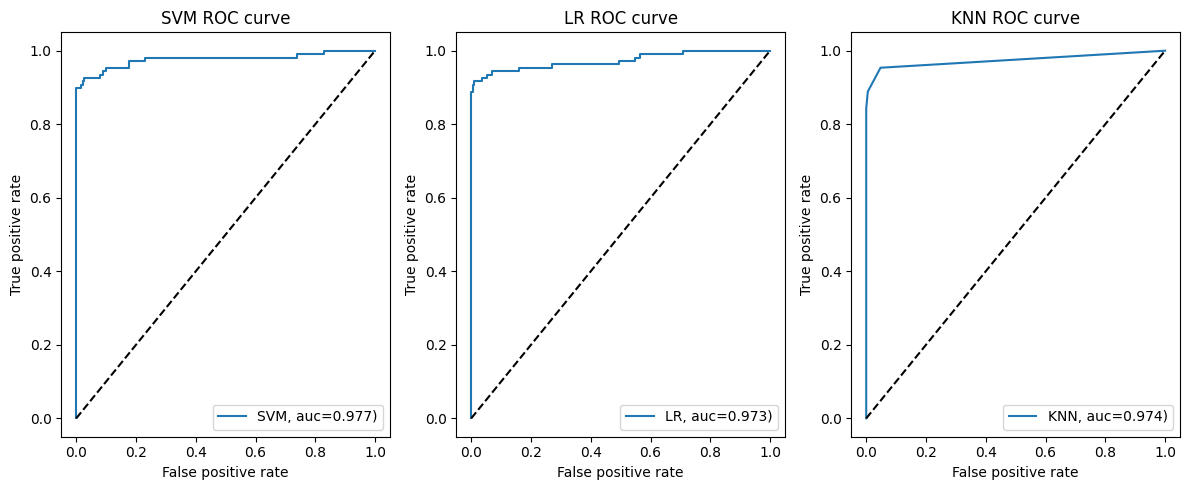

In [ ]:
#ROC
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

axes[0].plot(fpr_svm,tpr_svm,label="SVM, auc={:.3f})".format(auc_svm))
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[0].set_title('SVM ROC curve')
axes[0].legend(loc=4)

axes[1].plot(fpr_LR,tpr_LR,label="LR, auc={:.3f})".format(auc_LR))
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_xlabel('False positive rate')
axes[1].set_ylabel('True positive rate')
axes[1].set_title('LR ROC curve')
axes[1].legend(loc=4)

axes[2].plot(fpr_knn,tpr_knn,label="KNN, auc={:.3f})".format(auc_knn))
axes[2].plot([0, 1], [0, 1], 'k--')
axes[2].set_xlabel('False positive rate')
axes[2].set_ylabel('True positive rate')
axes[2].set_title('KNN ROC curve')
axes[2].legend(loc=4)

plt.tight_layout()
plt.show()